# 🌾 Rural Microfinance Bank: EDA & Target Engineering

Public microfinance datasets (like the rural Indian dataset we use here) almost never contain a `Default` column because NGOs and rural banks obscure this data.

Instead of predicting something useless (like the loan size), we will **mathematically engineer a realistic Risk/Default `TARGET`** based on true financial stress indicators extracted from the borrower's profile!

### Full Data Pipeline:
1. **Load** `RuralCreditData.csv`
2. **Handle Missing Values** & Clean up categorical strings
3. **Synthetic Target Engineering** ⭐ (Mathematically assign Risk logic)
4. **Encode** (Label Encoding & One-Hot Encoding)
5. **Save** Clean matrix to `data/processed/rural_microfinance/`

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')

RAW_PATH = '../../data/raw/rural_microfinance/'
df = pd.read_csv(RAW_PATH + 'RuralCreditData.csv')
print(f"Base Rural Data shape: {df.shape}")
df.head()

Base Rural Data shape: (40000, 21)


,Id,city,age,sex,social_class,primary_business,secondary_business,annual_income,monthly_expenses,old_dependents,...,home_ownership,type_of_house,occupants_count,house_area,sanitary_availability,water_availabity,loan_purpose,loan_tenure,loan_installments,loan_amount
0,1,Dhanbad,22,F,Mochi,Tailoring,Others,36000.0,5000.0,0,...,1.0,R,4,70.0,1.0,0.5,Apparels,12,12,5000.0
1,2,Manjapra,21,F,OBC,Tailoring,none,94000.0,3600.0,1,...,1.0,T1,4,80.0,1.0,0.5,Apparels,12,50,7500.0
2,3,Dhanbad,24,M,Nai,Beauty salon,Others,48000.0,4000.0,0,...,1.0,T1,4,50.0,1.0,0.5,Beauty Salon,12,12,5000.0
3,4,NaN,26,F,OBC,Tailoring,none,7000.0,5000.0,0,...,1.0,T1,5,50.0,1.0,0.5,Apparels,12,50,7500.0
4,5,Nuapada,23,F,OBC,General store,Agriculture,36000.0,3500.0,0,...,1.0,T1,1,112.0,1.0,0.5,Retail Store,12,12,5000.0


## Step 1: Handling Missing Values & Basic Cleanup

In [2]:
# Clean up column names (remove whitespaces, lowercase standard)
df.columns = df.columns.str.strip()

# Check missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("Missing columns found:")
    print(missing[missing > 0])
else:
    print("No missing values detected initially.")

# Fill numerically missing
num_cols = ['annual_income', 'monthly_expenses', 'loan_amount', 'loan_tenure', 'loan_installments', 'young_dependents', 'old_dependents']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill generically for text features
text_cols = ['secondary_business', 'home_ownership', 'type_of_house', 'primary_business']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')
        
print("Missing values resolved.")

Missing columns found:
city                     1864
social_class             5255
primary_business           26
secondary_business       5241
monthly_expenses          120
home_ownership            379
type_of_house             694
sanitary_availability     208
water_availabity         5253
loan_purpose               26
dtype: int64
Missing values resolved.


## Step 2: ⭐ Synthetic Target Engineering (Risk Assessment)

We will build a `TARGET` column (1 = Default, 0 = Repaid) by evaluating real-world financial stress.
Someone is highly likely to default if:
1. Their `loan_installments` swallow a large portion of their net disposable income.
2. They have a massive number of dependents taking up resources.
3. They are renting a house (unstable asset).
4. Small random noise injection to simulate reality because business type (`primary_business`), `age`, and random life events affect the outcome.

Synthetic Target Generated!
Default Rate: 15.00%


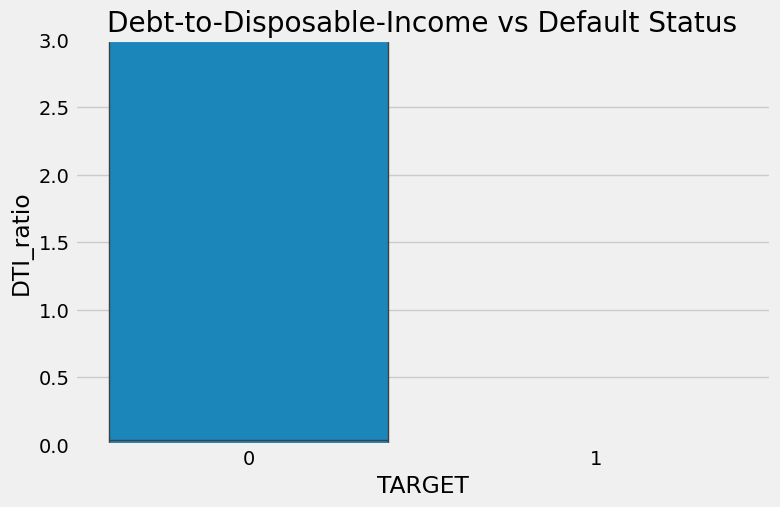

In [3]:
np.random.seed(42)

# 1. Calculate Disposable Income (per month)
# Note: annual_income is per year, expenses are monthly
df['net_disposable_income'] = (df['annual_income'] / 12) - df['monthly_expenses']

# 2. Prevent division by zero and negative incomes
df['net_disposable_income'] = df['net_disposable_income'].clip(lower=1)

# 3. Calculate Debt-to-Income Ratio (DTI)
df['DTI_ratio'] = df['loan_installments'] / df['net_disposable_income']

# 4. Total Dependents
df['total_dependents'] = df.get('young_dependents', 0) + df.get('old_dependents', 0)

# ----- APPLY LOGIC -----
# Base Risk Score (Continuous)
risk_score = (
    (df['DTI_ratio'] * 0.4) +                     # Huge weight on debt-to-income
    (df['total_dependents'] * 0.05) +             # Dependents add stress
    np.where(df['home_ownership'] == 'Rented', 0.15, 0.0) - # Renting penalty
    np.where(df.get('water_availabity', 0) == 1, 0.1, 0.0) - # Proxy for stability/infrastructure
    (df['age'] * 0.001)                           # Older age slightly reduces risk in standard models
)

# Add 15% random noise safely
noise = np.random.normal(0, 0.15, size=len(df))
final_risk = risk_score + noise

# Threshold: The top ~15% riskiest borrowers will default
# 85th percentile -> 15% default rate
threshold = np.percentile(final_risk, 85)
df['TARGET'] = (final_risk > threshold).astype(int)

print(f"Synthetic Target Generated!")
print(f"Default Rate: {df['TARGET'].mean() * 100:.2f}%")

# Visualize the separation
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y='DTI_ratio', data=df)
plt.title('Debt-to-Disposable-Income vs Default Status')
plt.ylim(0, 3) 
plt.show()

## Step 3: Encoding Categorical Features for XGBoost

In [4]:
# Drop ID and exact duplicates
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

# Drop raw 'city' if it has too many unique values (e.g. >100) or high cardinality
if 'city' in df.columns and df['city'].nunique() > 50:
    df.drop(columns=['city'], inplace=True)

# Binary Encoding
le = LabelEncoder()
binary_cats = ['sex', 'sanitary_availability', 'water_availabity']
for col in binary_cats:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# One-Hot Encoding for multi-class categorical features
multi_cats = ['social_class', 'primary_business', 'secondary_business', 
              'home_ownership', 'type_of_house', 'loan_purpose']

df = pd.get_dummies(df, columns=[c for c in multi_cats if c in df.columns], drop_first=True)

print(f"Shape after encoding: {df.shape}")

Shape after encoding: (40000, 1018)


## Step 4: Final Cleanup & Output

We remove mathematical infinities and save this engineered dataset! Now the `02_model_training.ipynb` file can be executed.

In [5]:
# Prevent XGBoost crashing from explicit inf values from DTI divisions
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True) # Any remaining weird divisions become 0

# Save
out_dir = '../../data/processed/rural_microfinance/'
os.makedirs(out_dir, exist_ok=True)
out_path = out_dir + 'cleaned_rural.csv'

df.to_csv(out_path, index=False)
print(f"✅ Saved clean Rural database to: {out_path}")

✅ Saved clean Rural database to: ../../data/processed/rural_microfinance/cleaned_rural.csv
